In [29]:
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# load your .env file
load_dotenv("../backend/.env")   # adjust path if needed

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:5432/{os.getenv('DB_NAME')}"
)

In [30]:
import pandas as pd
df_funnel = pd.read_sql("""
    with funnel as(
	select count(distinct case when event_type='signup_completed' then user_id end) as signup,
	count(distinct case when event_type='email_verified' then user_id end) as email,
	count(distinct case when event_type='onboarding_completed' then user_id end) as onboarding,
	count(distinct case when event_type='risk_quiz_completed' then user_id end) as risk_quiz,
	count(distinct case when event_type='kyc_completed' then user_id end) as kyc,
	count(distinct case when event_type='deposit_completed' then user_id end) as deposit,
	count(distinct case when event_type='portfolio_created' then user_id end) as portfolio
	from events
)
select 
	250000 as total_users,
	signup, round((signup*100/250000),1) as signup_pct,
	email, round((email*100/signup),1) as email_of_signup,
	onboarding,    ROUND(onboarding * 100.0 / email, 1)AS onboard_of_email,
    risk_quiz,     ROUND(risk_quiz * 100.0 / onboarding,1) AS quiz_of_onboard,
    kyc,           ROUND(kyc * 100.0 / risk_quiz, 1)   AS kyc_of_quiz,
    deposit,       ROUND(deposit * 100.0 / kyc, 1)     AS deposit_of_kyc,
    portfolio,     ROUND(portfolio * 100.0 / deposit, 1) AS portfolio_of_deposit
from funnel;
""", engine)

In [31]:
df_funnel

,total_users,signup,signup_pct,email,email_of_signup,onboarding,onboard_of_email,risk_quiz,quiz_of_onboard,kyc,kyc_of_quiz,deposit,deposit_of_kyc,portfolio,portfolio_of_deposit
0,250000,175014,70.0,148795,85.0,133748,89.9,55294,41.3,49324,89.2,32182,65.2,30551,94.9


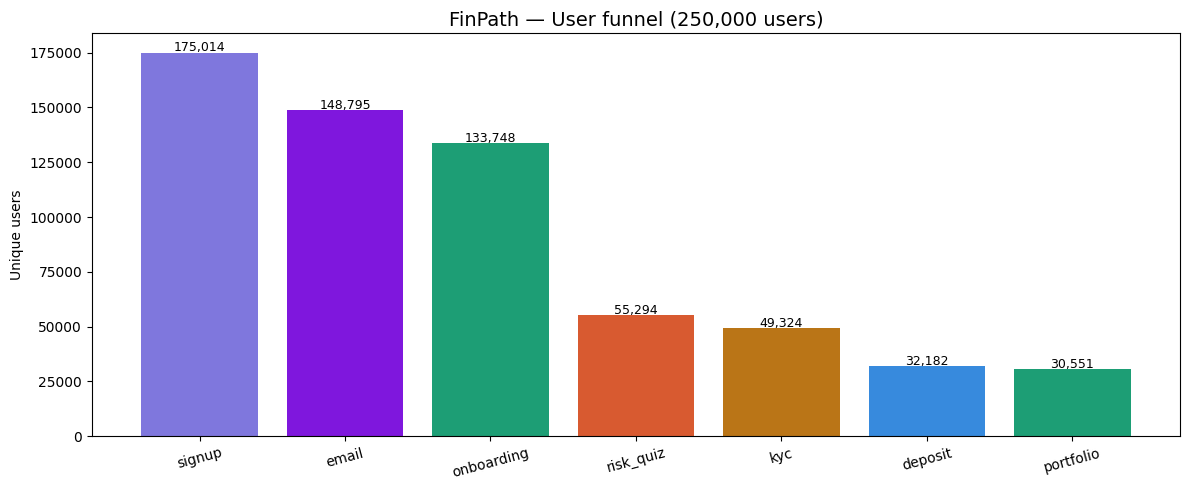

In [32]:
import matplotlib.pyplot as plt
stages = ['signup', 'email', 'onboarding', 'risk_quiz', 'kyc', 'deposit', 'portfolio']
values = [df_funnel[s].values[0] for s in stages]

plt.figure(figsize=(12, 5))
bars = plt.bar(stages, values, color=['#7F77DD','#7F17DD','#1D9E75',
                                       '#D85A30','#BA7517','#378ADD','#1D9E75'])
plt.title('FinPath — User funnel (250,000 users)', fontsize=14)
plt.ylabel('Unique users')
plt.xticks(rotation=15)

# add value labels on bars
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{int(val):,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('funnel_chart.png', dpi=150)
plt.show()

In [33]:
dropoff_query = """
WITH stage_events AS (
    SELECT
        user_id,
        MAX(CASE WHEN event_type = 'signup_completed'     THEN 1 ELSE 0 END) AS did_signup,
        MAX(CASE WHEN event_type = 'email_verified'       THEN 1 ELSE 0 END) AS did_email,
        MAX(CASE WHEN event_type = 'onboarding_completed' THEN 1 ELSE 0 END) AS did_onboard,
        MAX(CASE WHEN event_type = 'risk_quiz_completed'  THEN 1 ELSE 0 END) AS did_quiz,
        MAX(CASE WHEN event_type = 'kyc_completed'        THEN 1 ELSE 0 END) AS did_kyc,
        MAX(CASE WHEN event_type = 'deposit_completed'    THEN 1 ELSE 0 END) AS did_deposit,
        MAX(CASE WHEN event_type = 'portfolio_created'    THEN 1 ELSE 0 END) AS did_portfolio
    FROM events
    GROUP BY user_id
),
totals AS (
    SELECT
        SUM(did_signup)   AS s1,
        SUM(did_email)    AS s2,
        SUM(did_onboard)  AS s3,
        SUM(did_quiz)     AS s4,
        SUM(did_kyc)      AS s5,
        SUM(did_deposit)  AS s6,
        SUM(did_portfolio)AS s7
    FROM stage_events
)
SELECT stage, started, finished,
       started - finished AS dropped_off,
       ROUND((1 - finished::numeric / started) * 100, 1) AS dropoff_pct
FROM (
    SELECT 'signup → email'      AS stage, s1 AS started, s2 AS finished FROM totals
    UNION ALL
    SELECT 'email → onboarding',            s2, s3 FROM totals
    UNION ALL
    SELECT 'onboarding → quiz',             s3, s4 FROM totals
    UNION ALL
    SELECT 'quiz → kyc',                    s4, s5 FROM totals
    UNION ALL
    SELECT 'kyc → deposit',                 s5, s6 FROM totals
    UNION ALL
    SELECT 'deposit → portfolio',           s6, s7 FROM totals
) t
ORDER BY dropoff_pct DESC
"""


In [34]:
df_dropoff=pd.read_sql(dropoff_query,engine)
df_dropoff

,stage,started,finished,dropped_off,dropoff_pct
0,onboarding → quiz,133748,55294,78454,58.7
1,kyc → deposit,49324,32182,17142,34.8
2,signup → email,175014,148795,26219,15.0
3,quiz → kyc,55294,49324,5970,10.8
4,email → onboarding,148795,133748,15047,10.1
5,deposit → portfolio,32182,30551,1631,5.1


In [35]:
time_query = """
WITH user_timestamps AS (
    SELECT
        user_id,
        MIN(CASE WHEN event_type = 'signup_completed'     THEN timestamp END) AS t_signup,
        MIN(CASE WHEN event_type = 'email_verified'       THEN timestamp END) AS t_email,
        MIN(CASE WHEN event_type = 'onboarding_completed' THEN timestamp END) AS t_onboard,
        MIN(CASE WHEN event_type = 'risk_quiz_completed'  THEN timestamp END) AS t_quiz,
        MIN(CASE WHEN event_type = 'kyc_completed'        THEN timestamp END) AS t_kyc,
        MIN(CASE WHEN event_type = 'deposit_completed'    THEN timestamp END) AS t_deposit,
        MIN(CASE WHEN event_type = 'portfolio_created'    THEN timestamp END) AS t_portfolio
    FROM events
    GROUP BY user_id
),
diffs AS (
    SELECT
        EXTRACT(EPOCH FROM (t_email     - t_signup))   / 3600 AS hrs_to_email,
        EXTRACT(EPOCH FROM (t_onboard   - t_email))    / 3600 AS hrs_to_onboard,
        EXTRACT(EPOCH FROM (t_quiz      - t_onboard))  / 3600 AS hrs_to_quiz,
        EXTRACT(EPOCH FROM (t_kyc       - t_quiz))     / 3600 AS hrs_to_kyc,
        EXTRACT(EPOCH FROM (t_deposit   - t_kyc))      / 3600 AS hrs_to_deposit,
        EXTRACT(EPOCH FROM (t_portfolio - t_deposit))  / 3600 AS hrs_to_portfolio
    FROM user_timestamps
    WHERE t_signup IS NOT NULL
)
SELECT
    ROUND(AVG(hrs_to_email)::numeric,     1) AS avg_signup_to_email,
    ROUND(AVG(hrs_to_onboard)::numeric,   1) AS avg_email_to_onboard,
    ROUND(AVG(hrs_to_quiz)::numeric,      1) AS avg_onboard_to_quiz,
    ROUND(AVG(hrs_to_kyc)::numeric,       1) AS avg_quiz_to_kyc,
    ROUND(AVG(hrs_to_deposit)::numeric,   1) AS avg_kyc_to_deposit,
    ROUND(AVG(hrs_to_portfolio)::numeric, 1) AS avg_deposit_to_portfolio,

    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hrs_to_email)::numeric,     1) AS med_signup_to_email,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hrs_to_onboard)::numeric,   1) AS med_email_to_onboard,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hrs_to_quiz)::numeric,      1) AS med_onboard_to_quiz,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hrs_to_kyc)::numeric,       1) AS med_quiz_to_kyc,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hrs_to_deposit)::numeric,   1) AS med_kyc_to_deposit,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hrs_to_portfolio)::numeric, 1) AS med_deposit_to_portfolio
FROM diffs
"""

df_time = pd.read_sql(time_query, engine)
df_time

,avg_signup_to_email,avg_email_to_onboard,avg_onboard_to_quiz,avg_quiz_to_kyc,avg_kyc_to_deposit,avg_deposit_to_portfolio,med_signup_to_email,med_email_to_onboard,med_onboard_to_quiz,med_quiz_to_kyc,med_kyc_to_deposit,med_deposit_to_portfolio
0,36.6,1.1,168.2,196.0,204.5,0.1,36.6,1.1,168.4,195.9,204.0,0.1


In [36]:
avg_cols = [c for c in df_time.columns if c.startswith('avg')]
med_cols = [c for c in df_time.columns if c.startswith('med')]

df_display = pd.DataFrame({
    'stage':   ['signup→email', 'email→onboard', 'onboard→quiz',
                 'quiz→kyc', 'kyc→deposit', 'deposit→portfolio'],
    'avg_hrs': df_time[avg_cols].values[0],
    'med_hrs': df_time[med_cols].values[0]
})

df_display

,stage,avg_hrs,med_hrs
0,signup→email,36.6,36.6
1,email→onboard,1.1,1.1
2,onboard→quiz,168.2,168.4
3,quiz→kyc,196.0,195.9
4,kyc→deposit,204.5,204.0
5,deposit→portfolio,0.1,0.1


### Key insight — time metrics
- Users who verify email do it within ~1.5 days of signup
- The biggest time gap is **kyc → deposit** at ~9 days
  This is the most important re-engagement window —
  a nudge notification here could significantly improve deposit conversion
- deposit → portfolio happens almost instantly (same session)
  meaning users who deposit are highly motivated to invest immediately

In [37]:
cohort_query = """
WITH user_cohorts AS (
    -- Step 1: assign each user their signup week
    SELECT
        user_id,
        DATE_TRUNC('week', signup_at) AS cohort_week
    FROM users
),
user_activity AS (
    -- Step 2: find every week each user was active
    SELECT
        user_id,
        DATE_TRUNC('week', timestamp) AS active_week
    FROM events
    GROUP BY user_id, DATE_TRUNC('week', timestamp)
),
cohort_activity AS (
    -- Step 3: calculate weeks since signup for each activity
    SELECT
        c.cohort_week,
        EXTRACT(EPOCH FROM (a.active_week - c.cohort_week))
            / (7 * 86400)              AS weeks_since_signup,
        a.user_id
    FROM user_cohorts c
    JOIN user_activity a ON c.user_id = a.user_id
),
cohort_sizes AS (
    -- how many users in each cohort
    SELECT cohort_week, COUNT(*) AS cohort_size
    FROM user_cohorts
    GROUP BY cohort_week
)
SELECT
    TO_CHAR(ca.cohort_week, 'YYYY-MM-DD')   AS cohort_week,
    cs.cohort_size,
    SUM(CASE WHEN weeks_since_signup = 0  THEN 1 ELSE 0 END) AS week_0,
    SUM(CASE WHEN weeks_since_signup = 1  THEN 1 ELSE 0 END) AS week_1,
    SUM(CASE WHEN weeks_since_signup = 2  THEN 1 ELSE 0 END) AS week_2,
    SUM(CASE WHEN weeks_since_signup = 4  THEN 1 ELSE 0 END) AS week_4,
    SUM(CASE WHEN weeks_since_signup = 8  THEN 1 ELSE 0 END) AS week_8,
    SUM(CASE WHEN weeks_since_signup = 12 THEN 1 ELSE 0 END) AS week_12,

    -- as percentages of cohort size
    ROUND(SUM(CASE WHEN weeks_since_signup = 0  THEN 1 ELSE 0 END) * 100.0 / cs.cohort_size, 1) AS pct_w0,
    ROUND(SUM(CASE WHEN weeks_since_signup = 1  THEN 1 ELSE 0 END) * 100.0 / cs.cohort_size, 1) AS pct_w1,
    ROUND(SUM(CASE WHEN weeks_since_signup = 2  THEN 1 ELSE 0 END) * 100.0 / cs.cohort_size, 1) AS pct_w2,
    ROUND(SUM(CASE WHEN weeks_since_signup = 4  THEN 1 ELSE 0 END) * 100.0 / cs.cohort_size, 1) AS pct_w4,
    ROUND(SUM(CASE WHEN weeks_since_signup = 8  THEN 1 ELSE 0 END) * 100.0 / cs.cohort_size, 1) AS pct_w8,
    ROUND(SUM(CASE WHEN weeks_since_signup = 12 THEN 1 ELSE 0 END) * 100.0 / cs.cohort_size, 1) AS pct_w12

FROM cohort_activity ca
JOIN cohort_sizes cs ON ca.cohort_week = cs.cohort_week
GROUP BY ca.cohort_week, cs.cohort_size
ORDER BY ca.cohort_week
LIMIT 20
"""
df_cohort = pd.read_sql(cohort_query, engine)

# show only the percentage columns — cleaner to read
pct_cols = ['cohort_week', 'cohort_size', 'pct_w0', 'pct_w1', 
            'pct_w2', 'pct_w4', 'pct_w8', 'pct_w12']
df_cohort[pct_cols]

,cohort_week,cohort_size,pct_w0,pct_w1,pct_w2,pct_w4,pct_w8,pct_w12
0,2024-01-01,4794,100.0,46.7,26.4,13.4,2.3,2.0
1,2024-01-08,4733,100.0,47.7,25.5,12.4,2.1,1.7
2,2024-01-15,4578,100.0,47.2,26.9,14.0,2.1,1.9
3,2024-01-22,4828,100.0,47.8,26.7,12.9,2.2,2.0
4,2024-01-29,4835,100.0,48.5,28.4,14.4,2.3,2.4
5,2024-02-05,4849,100.0,47.6,27.3,13.2,2.1,2.2
6,2024-02-12,4842,100.0,46.9,26.8,13.7,2.1,2.4
7,2024-02-19,4817,100.0,46.3,27.3,13.5,2.1,1.9
8,2024-02-26,4753,100.0,47.6,27.0,13.4,1.7,2.1
9,2024-03-04,4863,100.0,48.2,26.9,12.6,1.9,1.7
